# 01 -- Exploratory Data Analysis: Marketing Mix Model

This notebook performs exploratory data analysis on the synthetic MMM weekly dataset.
We examine revenue trends, channel spend patterns, seasonality, correlations,
and the train/test split before proceeding to model development.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Paths
DATA_DIR = Path('../data/synthetic')
CSV_PATH = DATA_DIR / 'mmm_weekly_data.csv'
PARAMS_PATH = DATA_DIR / 'true_params.json'

# Load data
df = pd.read_csv(CSV_PATH, parse_dates=['date_week'])
df = df.sort_values('date_week').reset_index(drop=True)

with open(PARAMS_PATH, 'r') as f:
    true_params = json.load(f)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.date_week.min().date()} to {df.date_week.max().date()}')
print(f'\nTrue parameters keys: {list(true_params.keys())}')


Dataset shape: (208, 10)
Date range: 2015-11-23 to 2019-11-11

True parameters keys: ['channels', 'adstock_alphas', 'saturation_lambdas', 'betas', 'intercept', 'trend_coef', 'competitor_coef', 'event_coef', 'noise_sigma', 'fourier_coeffs']


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_week         208 non-null    datetime64[us]
 1   revenue           208 non-null    float64       
 2   tv_spend          208 non-null    float64       
 3   ooh_spend         208 non-null    float64       
 4   print_spend       208 non-null    float64       
 5   facebook_spend    208 non-null    float64       
 6   search_spend      208 non-null    float64       
 7   newsletter_sends  208 non-null    float64       
 8   competitor_index  208 non-null    float64       
 9   event_flag        208 non-null    int64         
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 16.4 KB


In [3]:
df.describe().round(2)

,date_week,revenue,tv_spend,ooh_spend,print_spend,facebook_spend,search_spend,newsletter_sends,competitor_index,event_flag
count,208,208.00,208.00,208.00,208.00,208.00,208.00,208.00,208.00,208.00
mean,2017-11-16 12:00:00,250000.00,19999.97,10000.02,7000.00,14999.97,11999.98,8141.20,1.00,0.14
min,2015-11-23 00:00:00,166531.36,4530.00,1966.00,967.00,2842.00,1194.00,6261.00,0.58,0.00
25%,2016-11-19 06:00:00,220590.10,11548.00,5343.25,3731.25,7707.25,7157.75,7417.75,0.92,0.00
50%,2017-11-16 12:00:00,252055.65,16440.50,8310.50,6012.50,12884.00,10448.00,8007.50,1.01,0.00
75%,2018-11-13 18:00:00,276705.26,25226.25,11932.50,8350.25,18629.00,14212.00,8675.75,1.09,0.00
max,2019-11-11 00:00:00,331498.90,85826.00,57897.00,29265.00,65389.00,71857.00,11452.00,1.33,1.00
std,NaN,37822.23,12813.32,7007.48,4670.62,9850.63,7868.12,1088.47,0.13,0.35


In [4]:
# Define channel columns and train/test split index
SPEND_COLS = ['tv_spend', 'ooh_spend', 'print_spend', 'facebook_spend', 'search_spend']
CONTROL_COLS = ['newsletter_sends', 'competitor_index', 'event_flag']
TRAIN_END = 156  # first 156 weeks = training

df_train = df.iloc[:TRAIN_END].copy()
df_test = df.iloc[TRAIN_END:].copy()

print(f'Training set: {len(df_train)} weeks ({df_train.date_week.min().date()} to {df_train.date_week.max().date()})')
print(f'Test set:     {len(df_test)} weeks ({df_test.date_week.min().date()} to {df_test.date_week.max().date()})')

Training set: 156 weeks (2015-11-23 to 2018-11-12)
Test set:     52 weeks (2018-11-19 to 2019-11-11)


## 2. Revenue Time Series

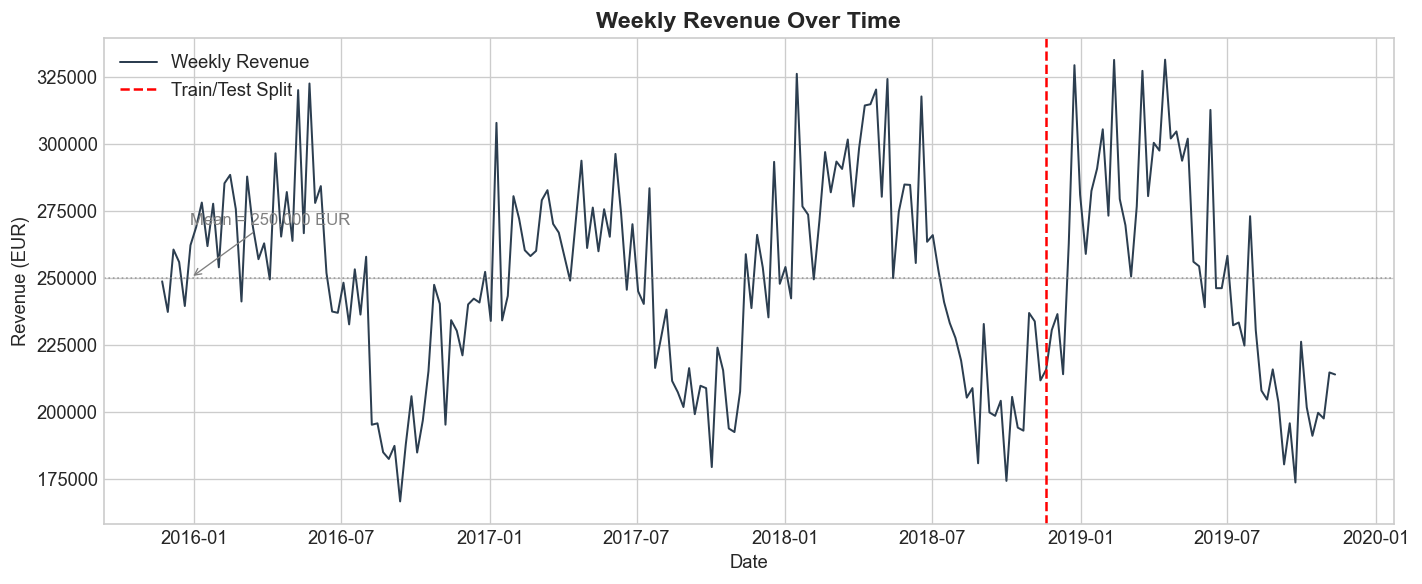

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['date_week'], df['revenue'], color='#2c3e50', linewidth=1.2, label='Weekly Revenue')

# Train/test split line
split_date = df.iloc[TRAIN_END]['date_week']
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')

# Mean revenue annotation
mean_rev = df['revenue'].mean()
ax.axhline(y=mean_rev, color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.annotate(f'Mean = {mean_rev:,.0f} EUR', xy=(df['date_week'].iloc[5], mean_rev),
            xytext=(df['date_week'].iloc[5], mean_rev * 1.08),
            fontsize=10, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax.set_title('Weekly Revenue Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (EUR)')
ax.legend(loc='upper left')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## 3. Channel Spend Time Series

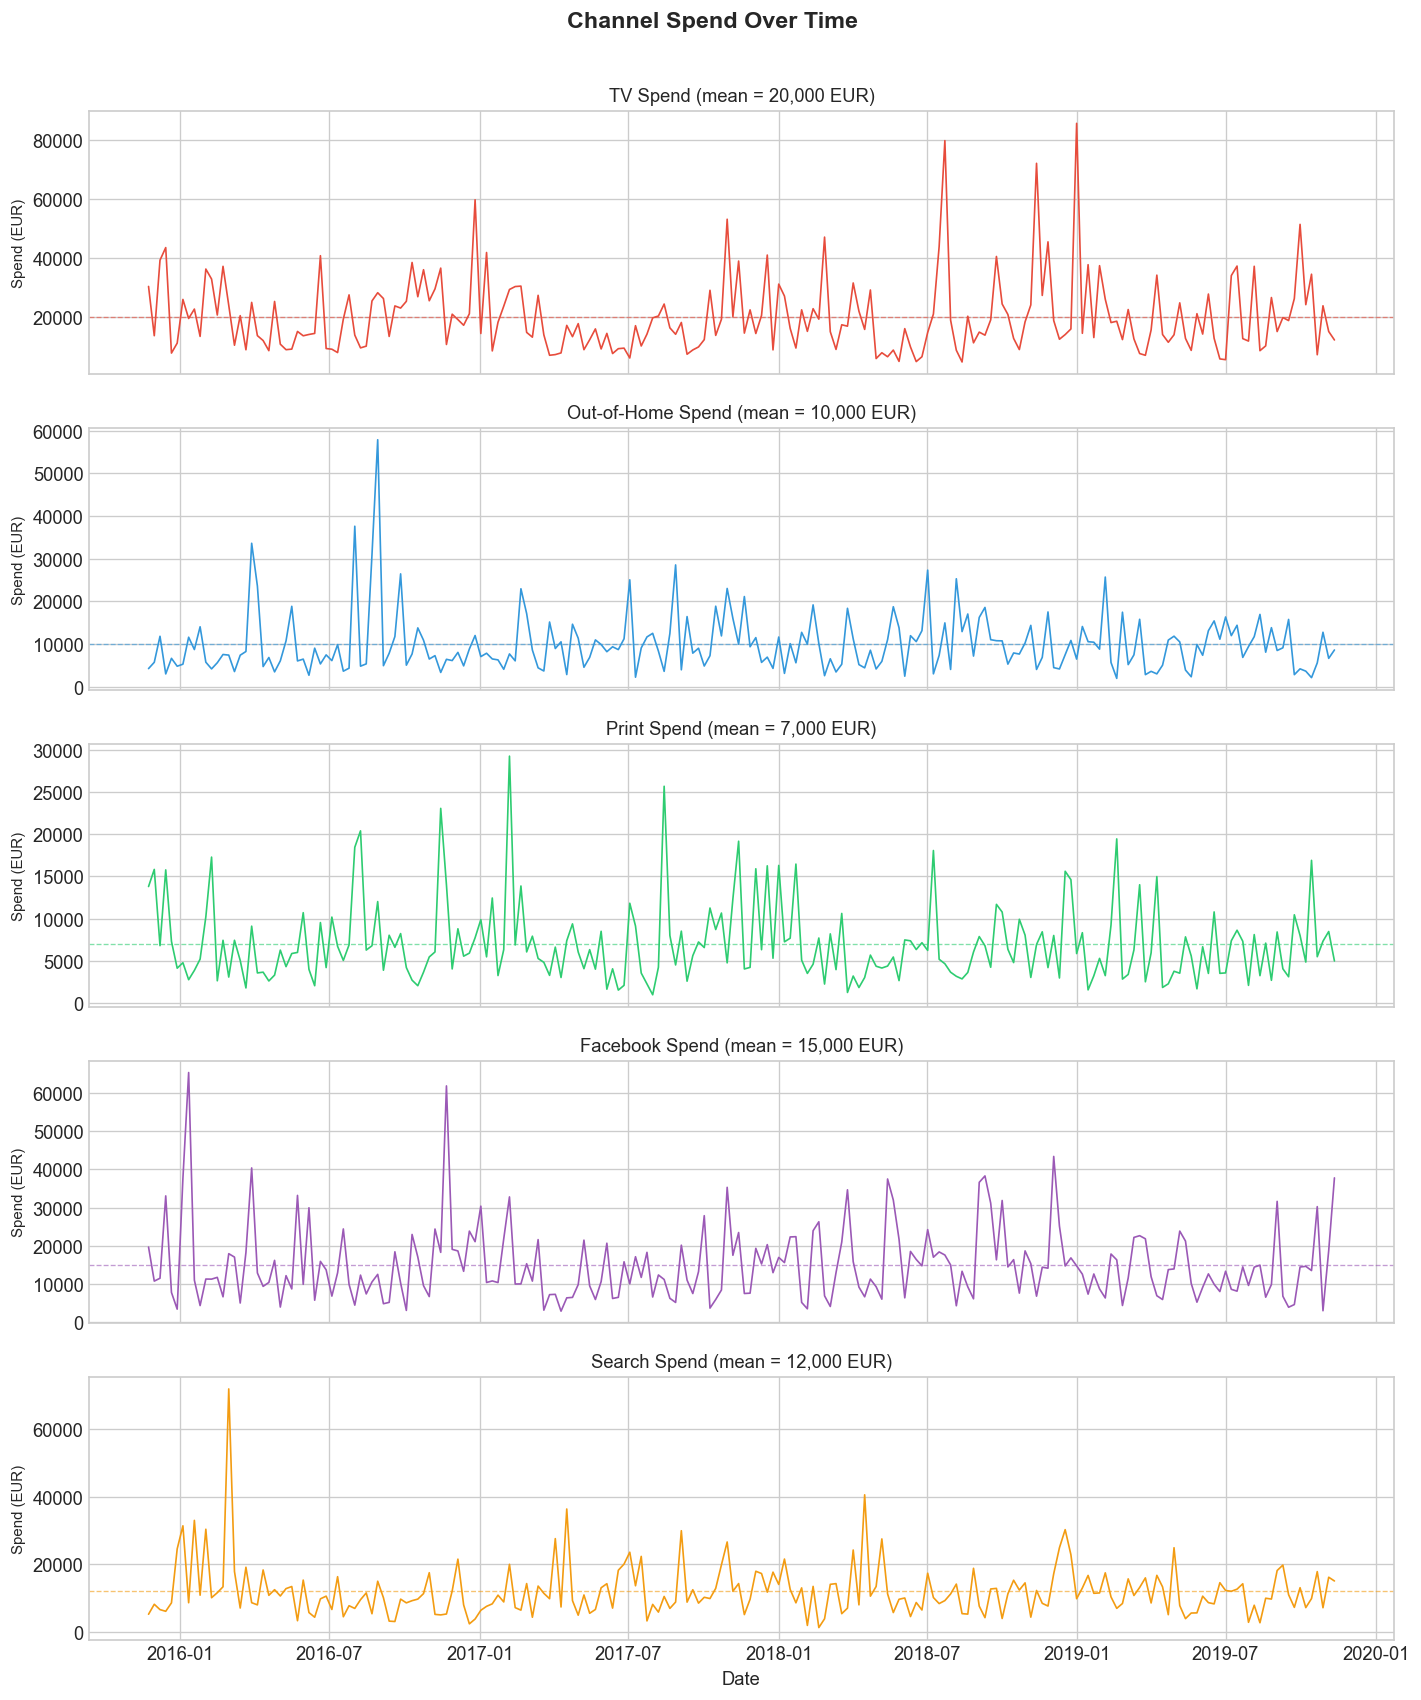

In [6]:
channel_colors = {
    'tv_spend': '#e74c3c',
    'ooh_spend': '#3498db',
    'print_spend': '#2ecc71',
    'facebook_spend': '#9b59b6',
    'search_spend': '#f39c12'
}

channel_labels = {
    'tv_spend': 'TV',
    'ooh_spend': 'Out-of-Home',
    'print_spend': 'Print',
    'facebook_spend': 'Facebook',
    'search_spend': 'Search'
}

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, col in zip(axes, SPEND_COLS):
    color = channel_colors[col]
    label = channel_labels[col]
    ax.plot(df['date_week'], df[col], color=color, linewidth=1.0, label=label)
    mean_val = df[col].mean()
    ax.axhline(y=mean_val, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Spend (EUR)', fontsize=9)
    ax.set_title(f'{label} Spend (mean = {mean_val:,.0f} EUR)', fontsize=11)
    ax.ticklabel_format(style='plain', axis='y')

axes[-1].set_xlabel('Date')
fig.suptitle('Channel Spend Over Time', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Revenue vs Spend Correlation

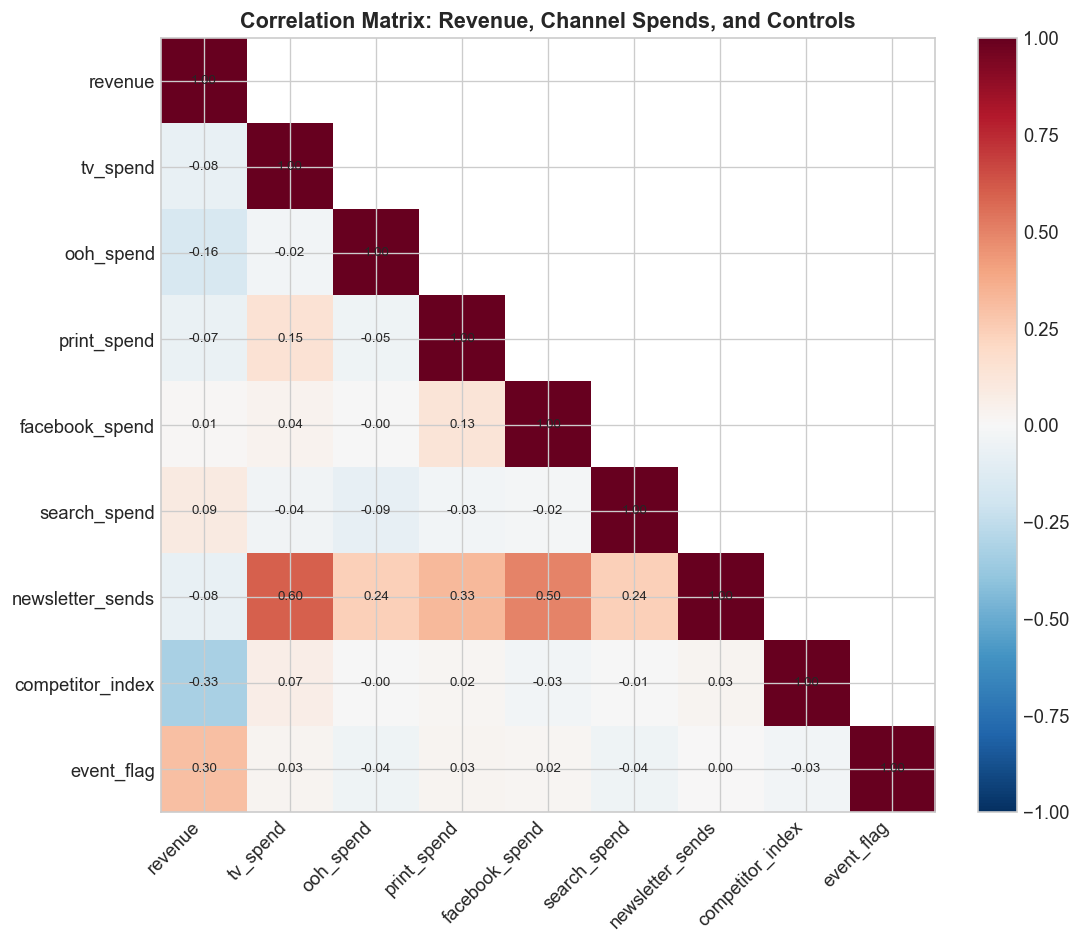

In [7]:
# Correlation heatmap
corr_cols = ['revenue'] + SPEND_COLS + CONTROL_COLS
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

if sns is not None:
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
else:
    # Matplotlib fallback when seaborn is unavailable.
    masked = corr_matrix.mask(mask)
    im = ax.imshow(masked, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)
    for r in range(masked.shape[0]):
        for c in range(masked.shape[1]):
            val = masked.iat[r, c]
            if not np.isnan(val):
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title('Correlation Matrix: Revenue, Channel Spends, and Controls', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


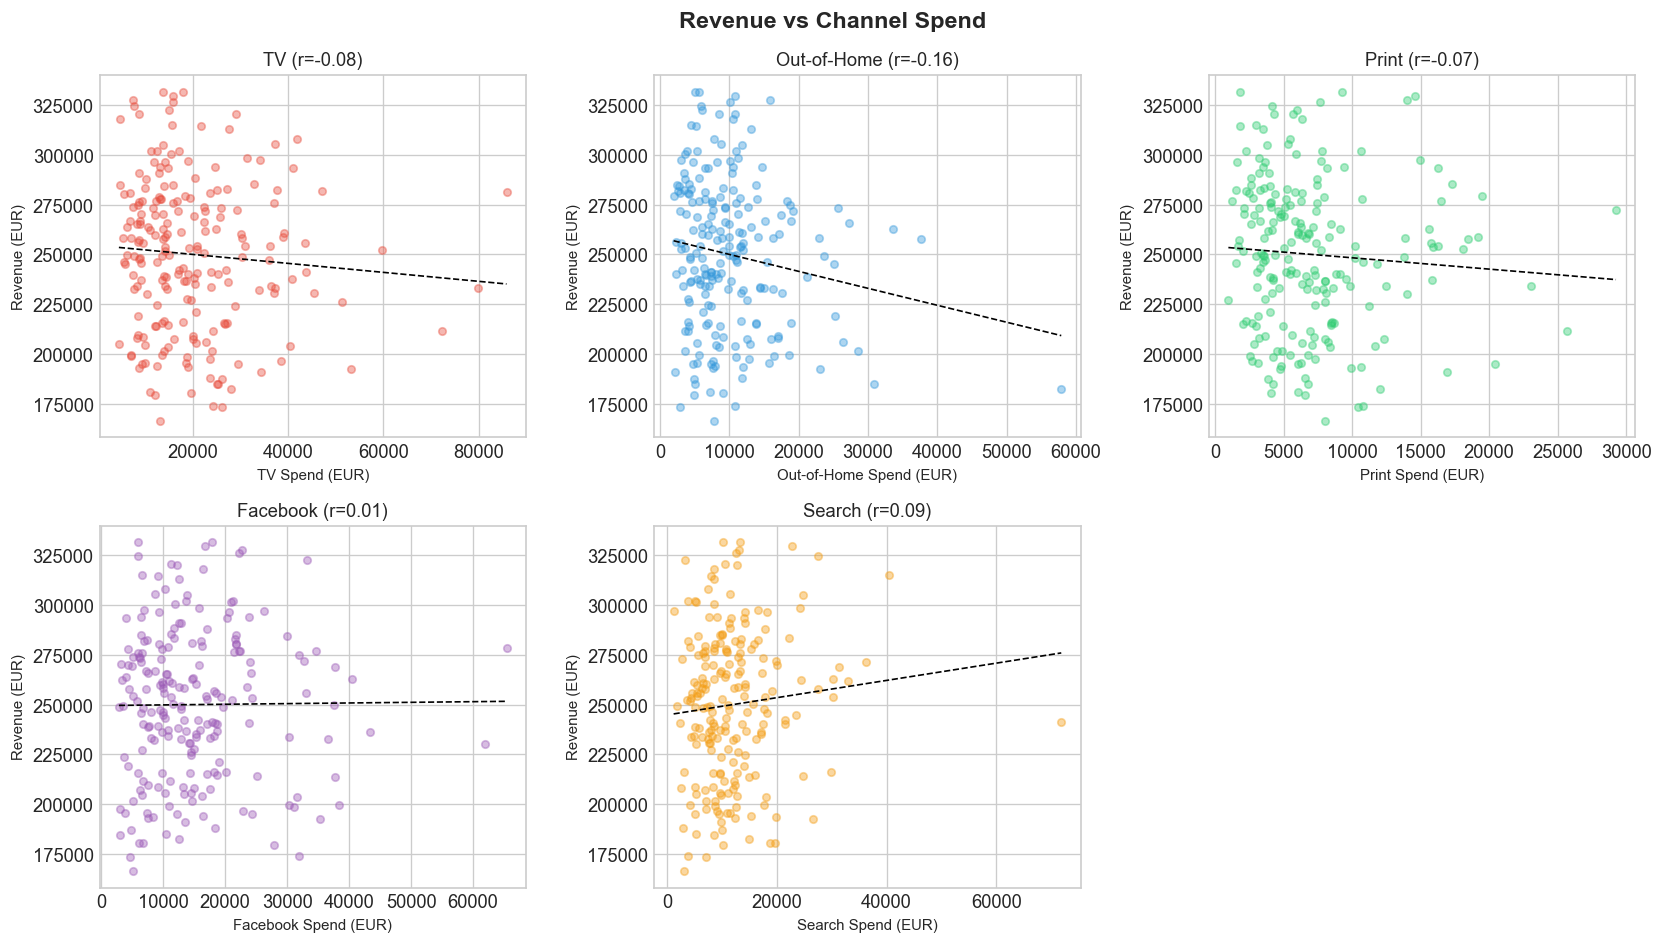

In [8]:
# Scatter plots: revenue vs each channel spend
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SPEND_COLS):
    ax = axes[i]
    color = channel_colors[col]
    label = channel_labels[col]
    ax.scatter(df[col], df['revenue'], alpha=0.4, s=20, color=color)
    # Add trend line
    z = np.polyfit(df[col], df['revenue'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1)
    r = df[col].corr(df['revenue'])
    ax.set_title(f'{label} (r={r:.2f})', fontsize=11)
    ax.set_xlabel(f'{label} Spend (EUR)', fontsize=9)
    ax.set_ylabel('Revenue (EUR)', fontsize=9)
    ax.ticklabel_format(style='plain', axis='both')

# Hide the 6th subplot
axes[5].set_visible(False)

fig.suptitle('Revenue vs Channel Spend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Seasonality Analysis

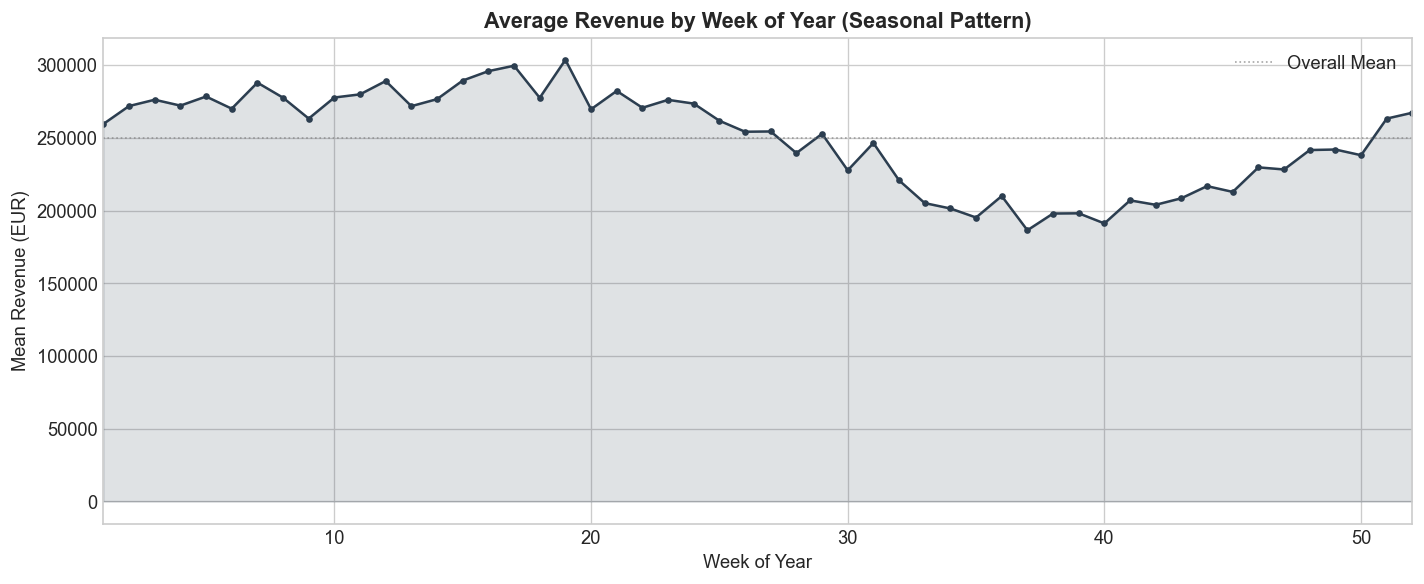

In [9]:
# Revenue by week-of-year
df['week_of_year'] = df['date_week'].dt.isocalendar().week.astype(int)

weekly_seasonal = df.groupby('week_of_year')['revenue'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly_seasonal.index, weekly_seasonal.values, color='#2c3e50', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(weekly_seasonal.index, weekly_seasonal.values, alpha=0.15, color='#2c3e50')
ax.axhline(y=df['revenue'].mean(), color='grey', linestyle=':', linewidth=1, alpha=0.7, label='Overall Mean')
ax.set_title('Average Revenue by Week of Year (Seasonal Pattern)', fontsize=13, fontweight='bold')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Mean Revenue (EUR)')
ax.set_xlim(1, 52)
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

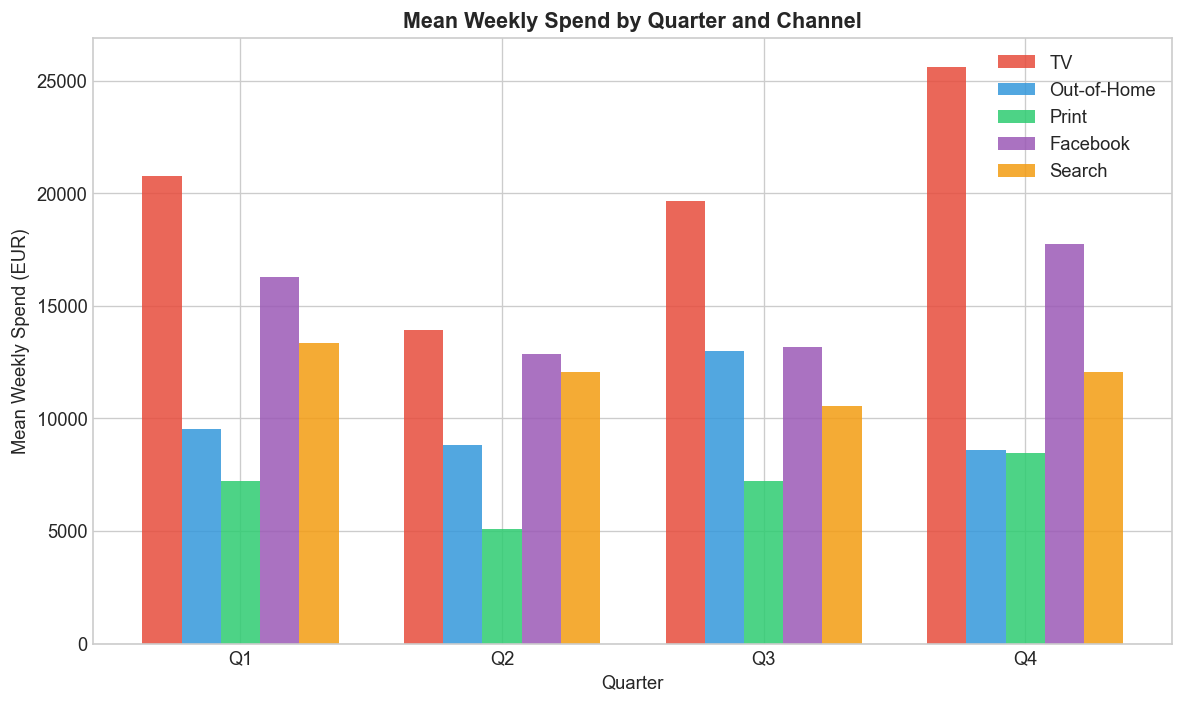

In [10]:
# Mean spend by quarter for each channel
df['quarter'] = df['date_week'].dt.quarter

quarterly_spend = df.groupby('quarter')[SPEND_COLS].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
width = 0.15

for i, col in enumerate(SPEND_COLS):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, quarterly_spend[col], width,
                  label=channel_labels[col], color=channel_colors[col], alpha=0.85)

ax.set_title('Mean Weekly Spend by Quarter and Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Mean Weekly Spend (EUR)')
ax.set_xticks(x)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.legend(loc='upper right')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## 6. Spend Distribution

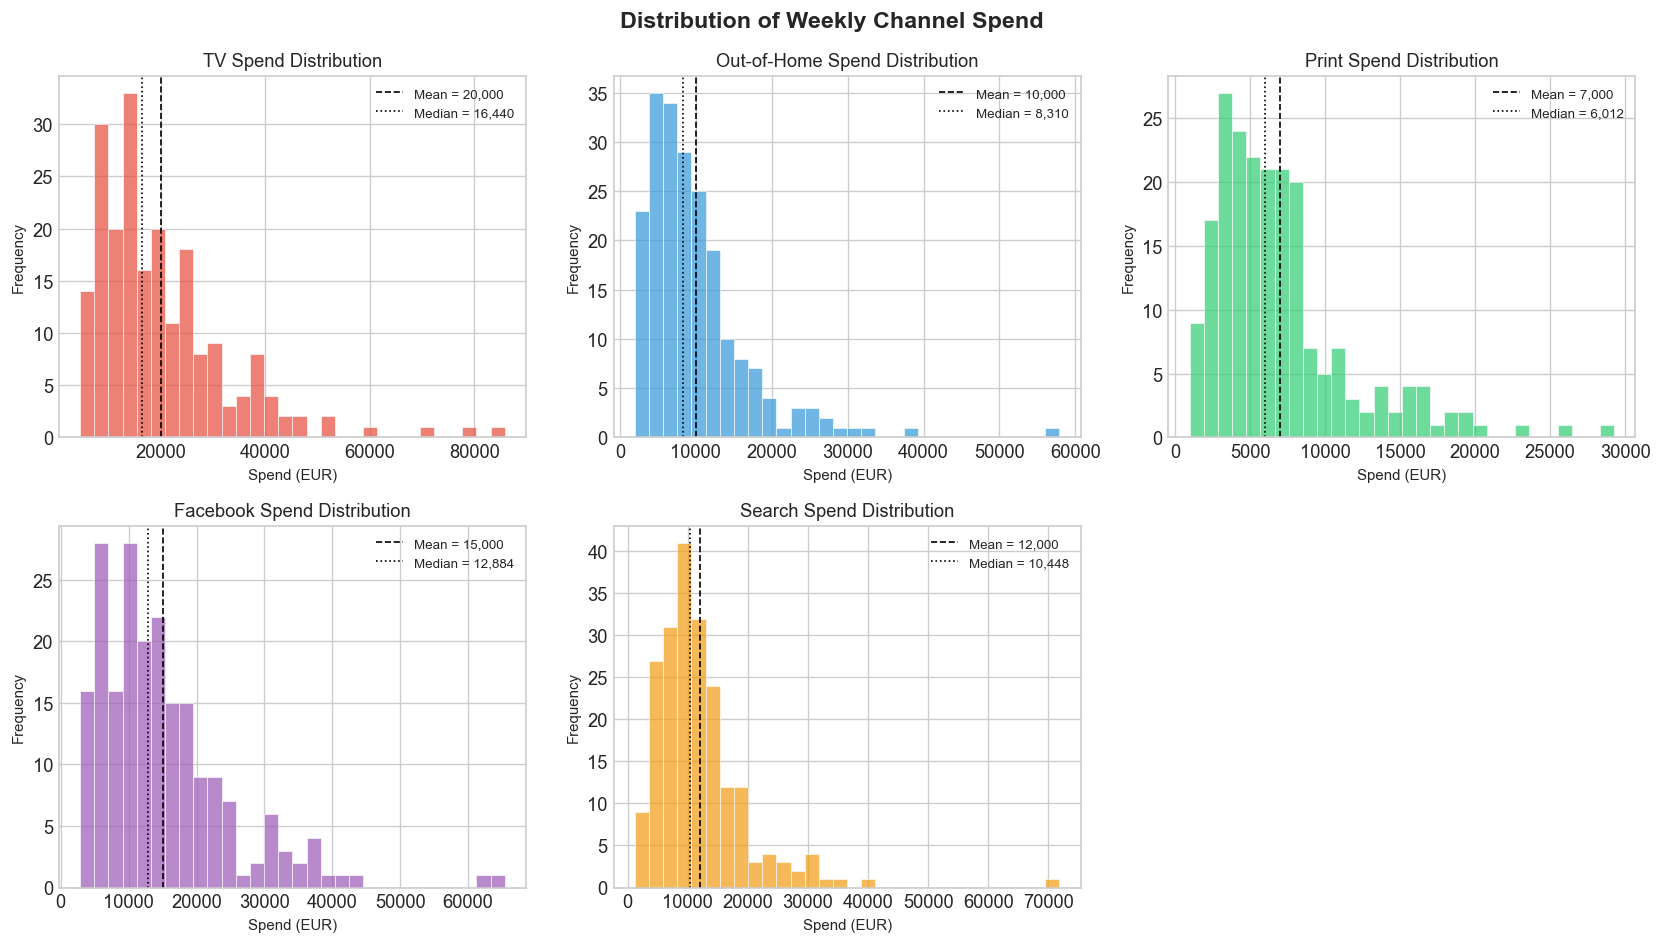

In [11]:
# Histograms of each channel's weekly spend
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SPEND_COLS):
    ax = axes[i]
    color = channel_colors[col]
    label = channel_labels[col]
    ax.hist(df[col], bins=30, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean = {df[col].mean():,.0f}')
    ax.axvline(df[col].median(), color='black', linestyle=':', linewidth=1, label=f'Median = {df[col].median():,.0f}')
    ax.set_title(f'{label} Spend Distribution', fontsize=11)
    ax.set_xlabel('Spend (EUR)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.ticklabel_format(style='plain', axis='x')

axes[5].set_visible(False)

fig.suptitle('Distribution of Weekly Channel Spend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/tf/298fp4vx4tz69ft6bbq8xlj80000gn/T/ipykernel_30950/2619879153.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[col].values for col in SPEND_COLS],


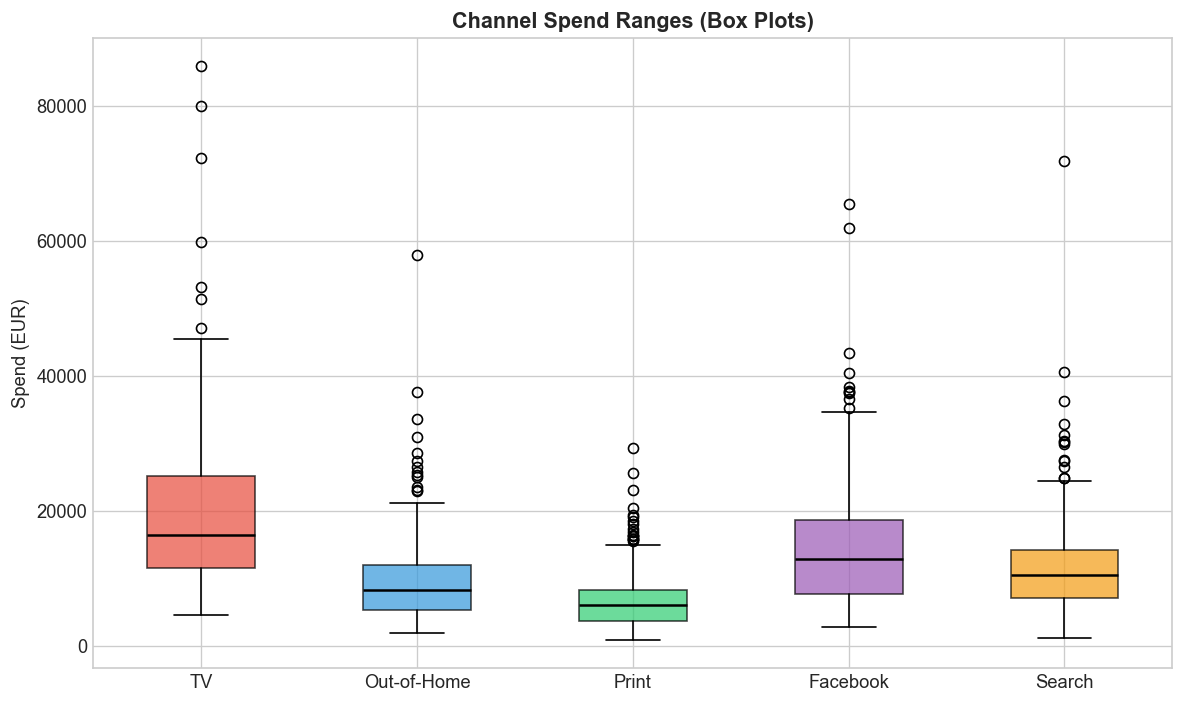

In [12]:
# Box plots comparing channel spend ranges
spend_melted = df[SPEND_COLS].melt(var_name='Channel', value_name='Spend')
spend_melted['Channel'] = spend_melted['Channel'].map(channel_labels)

fig, ax = plt.subplots(figsize=(10, 6))
box_colors = [channel_colors[col] for col in SPEND_COLS]

bp = ax.boxplot([df[col].values for col in SPEND_COLS],
                labels=[channel_labels[col] for col in SPEND_COLS],
                patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Channel Spend Ranges (Box Plots)', fontsize=13, fontweight='bold')
ax.set_ylabel('Spend (EUR)')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## 7. Train/Test Split Visualization

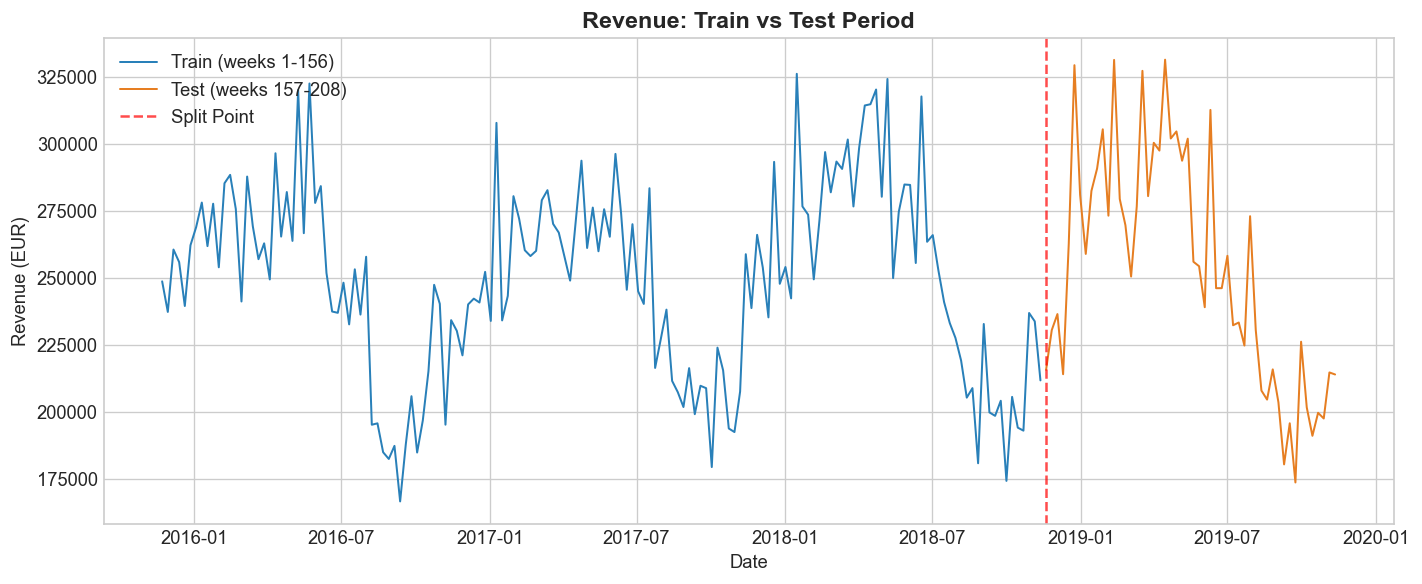

In [13]:
# Overlay plot: train (blue) and test (orange) revenue
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_train['date_week'], df_train['revenue'], color='#2980b9', linewidth=1.2, label='Train (weeks 1-156)')
ax.plot(df_test['date_week'], df_test['revenue'], color='#e67e22', linewidth=1.2, label='Test (weeks 157-208)')
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Split Point')

ax.set_title('Revenue: Train vs Test Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (EUR)')
ax.legend(loc='upper left')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [14]:
# Summary statistics: train vs test
summary_cols = ['revenue'] + SPEND_COLS + ['newsletter_sends', 'competitor_index']

train_stats = df_train[summary_cols].describe().loc[['mean', 'std', 'min', 'max']].T
test_stats = df_test[summary_cols].describe().loc[['mean', 'std', 'min', 'max']].T

comparison = pd.DataFrame({
    'Train Mean': train_stats['mean'],
    'Test Mean': test_stats['mean'],
    'Diff (%)': ((test_stats['mean'] - train_stats['mean']) / train_stats['mean'] * 100),
    'Train Std': train_stats['std'],
    'Test Std': test_stats['std'],
    'Train Min': train_stats['min'],
    'Test Min': test_stats['min'],
    'Train Max': train_stats['max'],
    'Test Max': test_stats['max']
})

print('Train vs Test Distribution Comparison')
print('=' * 80)
comparison.round(2)

Train vs Test Distribution Comparison


,Train Mean,Test Mean,Diff (%),Train Std,Test Std,Train Min,Test Min,Train Max,Test Max
revenue,248963.12,253110.63,1.67,35957.27,43169.44,166531.36,173609.41,326220.41,331498.90
tv_spend,19684.35,20946.83,6.41,12373.33,14137.28,4530.00,5315.00,79935.00,85826.00
ooh_spend,10243.78,9268.75,-9.52,7542.04,5069.77,2239.00,1966.00,57897.00,25715.00
print_spend,7135.44,6593.71,-7.59,4818.50,4213.48,967.00,1548.00,29265.00,19452.00
facebook_spend,15268.67,14193.88,-7.04,10304.77,8380.62,2842.00,2955.00,65389.00,43399.00
search_spend,11968.97,12093.02,1.04,8469.76,5764.99,1194.00,2619.00,71857.00,30188.00
newsletter_sends,8135.67,8157.79,0.27,1115.72,1012.46,6261.00,6283.00,11452.00,11397.00
competitor_index,1.00,0.98,-1.97,0.12,0.15,0.76,0.58,1.25,1.33


## 8. Summary of Key EDA Findings

**Dataset overview:**
- 208 weeks of synthetic marketing mix data spanning approximately four years.
- Five paid media channels (TV, out-of-home, print, Facebook, search), one organic channel (newsletter), and two control variables (competitor index, event flag).

**Revenue patterns:**
- Revenue exhibits a visible seasonal pattern when aggregated by week-of-year, consistent with the Fourier terms included in the feature engineering step.
- There may be a slight upward or stable trend over the observation window.

**Channel spend observations:**
- Channel spend levels vary substantially across channels. Some channels operate at consistently higher weekly budgets than others.
- Spend distributions tend to be roughly symmetric for most channels, though some may show occasional zero-spend weeks or outlier pulses.

**Correlations:**
- Raw (unconditional) correlations between channel spend and revenue provide an initial signal but do not account for adstock carryover, saturation, or confounding from trend/seasonality.
- The correlation heatmap shows the strength and direction of linear associations, but the MMM model will need to disentangle these effects properly.

**Train/test comparability:**
- The 75/25 chronological split preserves temporal ordering. The comparison table above confirms whether the test set is distributionally similar to training or shows drift.
- Any notable shift in mean spend or revenue between periods should be kept in mind when interpreting out-of-sample model performance.

**Next steps:**
- Apply adstock (geometric decay) and saturation (Hill function) transformations to media spend variables.
- Fit the Bayesian MMM and validate parameter recovery against the ground-truth values in `true_params.json`.